# NextGEMS data

| [![NextGEMS-badge]][NextGEMS-url] |
|:-:|

[NextGEMS-badge]: https://img.shields.io/badge/NextGEMS-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[NextGEMS-url]: https://easy.gems.dkrz.de/DYAMOND/NextGEMS/index.html

## Experiment Details and Available Data Fields

The dataset comprises output data from an ICON run within the 4th model cycle phase of the NextGEMS project (NGC4008). This simulation spans a total of 30 years and uses an ssp370-like scenario run from 2020.
The simulation was performed using a horizontal grid spacing of approximately 100 km (R2B8/8). 
A global, coupled simulation covering a time period of 1000 years, starting in 1300, was run. 48-hourly output data were generated throughout the simulation.
However, only a subset of the data is provided: three months of data for four selected variables at three model levels.
The data are stored on a HEALPix grid with lossless compression, and the total size of the available dataset is approximately 9 GB.

The dataset is contained in a Zarr directory. The data are available for reuse under the Creative Commons Attribution 4.0 International (CC BY 4.0) license: <https://creativecommons.org/licenses/by/4.0/>.

The following 2D parameters are available:
```python
["hus", "pr", "ua", "va"]
```
The following model levels are available:
```python
[89, 65, 55]
```


The available time steps begin at 2020-01-02 00:00:00 UTC, increasing in 2-day steps until 2020-03-31 00:00:00 UTC.



## Using the `load_NextGEMS_data` Function

To load the Zarr directory, you can use the following function:

```python
load_NextGEMS_data()
```

This function is straightforward and does not require any parameters.


In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

First, the package `zarr` (modern dataset format that is specifically designed for chunked access) and its dependencies need to be imported for the remote access.

The `load_NextGEMS_data` function simplifies remote access to Zarr datasets stored on the S3 bucket. It loads the data efficiently as an xarray dataset.


In [3]:
import xarray as xr


def load_NextGEMS_data():
    url = f"{BASE_URL}/EW3_ICON_ngc4008_90d_Compression_test.zarr"

    print(f"Loading dataset {url}")

    return xr.open_dataset(url, engine="zarr", chunks={})

[pyodide]: Loading numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loaded numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 61 new dynamic libraries (64 total for this notebook)


## Example Usage

To load the Zarr directory, you can use the following example. This will load the whole dataset. 

In [4]:
ds = load_NextGEMS_data()
ds

Loading dataset https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/EW3_ICON_ngc4008_90d_Compression_test.zarr
[pyodide]: Loading Deprecated, donfig, google-crc32c, numcodecs, typing_extensions, wrapt, zarr
[pyodide]: Loaded Deprecated, donfig, google-crc32c, numcodecs, typing_extensions, wrapt, zarr
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Loading pathlib_abc, universal_pathlib
[pyodide]: Loaded pathlib_abc, universal_pathlib
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Loading aiohappyeyeballs, aiohttp, aiosignal, attrs, frozenlist, multidict, propcache, yarl
[pyodide]: Loaded aiohappyeyeballs, aiohttp, aiosignal, attrs, frozenlist, multidict, propcache, yarl
[pyodide]: Loading pydantic_core
[pyodide]: Loaded pydantic_core
[pyodide]: Loading Jinja2, MarkupSafe
[pyodide]: Loaded Jinja2, MarkupSafe
[pyodide]: Loading Pint, flexcache, flexparser, platformdirs
[pyodide]: Loaded Pint, flexcache, flex

<xarray.Dataset> Size: 11GB
Dimensions:     (time: 90, level_full: 3, cell: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 720B 2020-01-02 2020-01-03 ... 2020-03-31
  * level_full  (level_full) float64 24B 89.0 65.0 55.0
Dimensions without coordinates: cell
Data variables:
    hus         (time, level_full, cell) float32 3GB dask.array<chunksize=(3, 1, 196608), meta=np.ndarray>
    pr          (time, cell) float32 1GB dask.array<chunksize=(3, 196608), meta=np.ndarray>
    ua          (time, level_full, cell) float32 3GB dask.array<chunksize=(3, 1, 196608), meta=np.ndarray>
    va          (time, level_full, cell) float32 3GB dask.array<chunksize=(3, 1, 196608), meta=np.ndarray>

[pyodide]: Memory usage has grown to 155.4MiB (from 107.9MiB) for this notebook
[pyodide]: Loaded 48 new dynamic libraries (112 total for this notebook)


The `earthkit.plots` package is used for plotting the data.

In [5]:
import earthkit.plots

from utils import quickplot

[pyodide]: Loading Cartopy, Markdown, adjustText, array-api-compat, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, shapely, tqdm
[pyodide]: Loaded Cartopy, Markdown, adjustText, array-api-compat, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, shapely, tqdm
[pyodide]: Loading earthkit-plots-default-styles
[pyodide]: Loaded earthkit-plots-default-styles
[pyodide]: Memory us

The data on the HEALPix grid can be visualized as demonstrated below. For example, the specific humidity on **2020-02-01 at 00:00:00 UTC** at model level 89 is plotted.

In [6]:
da_hus = ds.hus.sel(time="2020-02-01T00:00:00", level_full=89.0)

[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading atlaslib-ecmwf, earthkit-geo, mir-python, mirlib
[pyodide]: Loaded atlaslib-ecmwf, earthkit-geo, mir-python, mirlib
[pyodide]: Loading ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipywidgets, jupyterlab_widgets


[CORS]: The origin https://sites.ecmwf.int does not support Cross-Origin Resource Sharing.
        Requests to this origin are being proxied, which may reduce performance.

        Please ask the maintainers of https://sites.ecmwf.int to enable CORS using the
        Access-Control-Allow-Origin header.

        Please see https://developer.mozilla.org/en-US/docs/Web/HTTP/CORS for
        more information about Cross-Origin Resource Sharing.
/lib/python3.14/site-packages/earthkit/geo/utils/__init__.py:21: TqdmMonitorWarning: tqdm:disabling monitor support (monitor_interval = 0) due to:
can't start new thread
  return tqdm(


3e88ee5131d00f81d46178e5c61ba32c891feec500e64a3a6c2523f99dfeb64b.npz:   0%|          | 0.00/26.5M [00:00<?, ?B…

/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


[pyodide]: Memory usage has grown to 661.1MiB (from 186.6MiB) for this notebook
[pyodide]: Loaded 84 new dynamic libraries (202 total for this notebook)


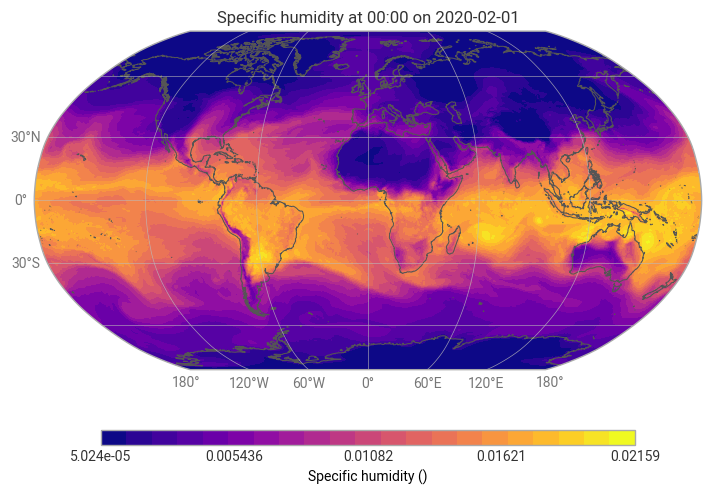

In [7]:
gridspec = {
    "type": "healpix",
    "grid": "H512",
    "ordering": "nested",
}

quickplot(
    da_hus,
    method="quickplot",
    chart=earthkit.plots.Map(crs="Robinson"),
    metadata={"gridSpec": gridspec},
)

The `pyicon` library can also be used to visualize the data as demonstrated below.

[pyodide]: Loading astropy, astropy-iers-data, cmocean, healpy, intake, networkx, pyerfa, pyicon-diagnostics
[pyodide]: Loaded astropy, astropy-iers-data, cmocean, healpy, intake, networkx, pyerfa, pyicon-diagnostics
----Start loading pyicon.
Loading default parameters from /lib/python3.14/site-packages/pyicon/params_default.json.
[pyodide]: Loading decorator, ipdb
[pyodide]: Loaded decorator, ipdb
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.
[pyodide]: Loading sortedcontainers
[pyodide]: Loaded sortedcontainers
[pyodide]: Loading beautifulsoup4, soupsieve
[pyodide]: Loaded beautifulsoup4, soupsieve
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading lxml
[pyodide]: Loaded lxml


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


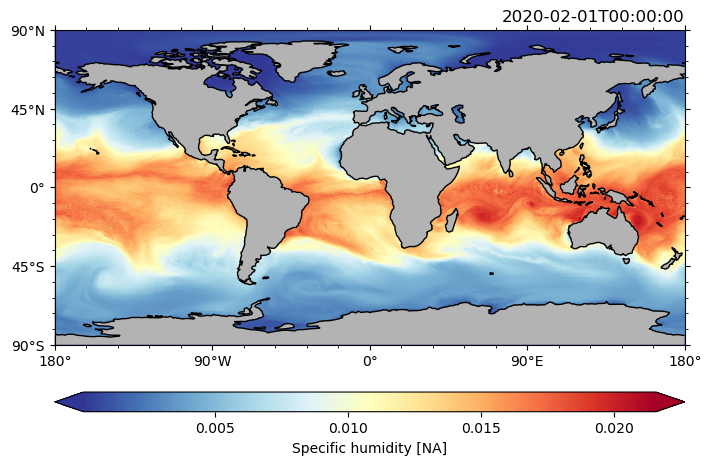

[pyodide]: Memory usage has grown to 863.6MiB (from 661.1MiB) for this notebook
[pyodide]: Loaded 25 new dynamic libraries (227 total for this notebook)


In [8]:
import matplotlib.pyplot as plt
import pyicon as pyic

da_hus.pyic.plot()
plt.show()

Zonal and Meridional wind can be visualized in the same way.


The precipitation flux on **2020-03-31 at 00:00:00 UTC** is plotted as demonstrated below.


In [9]:
da_pr = ds.pr.sel(time="2020-03-31T00:00:00")

3e88ee5131d00f81d46178e5c61ba32c891feec500e64a3a6c2523f99dfeb64b.npz:   0%|          | 0.00/26.5M [00:00<?, ?B…

[pyodide]: Memory usage has grown to 963.8MiB (from 863.6MiB) for this notebook


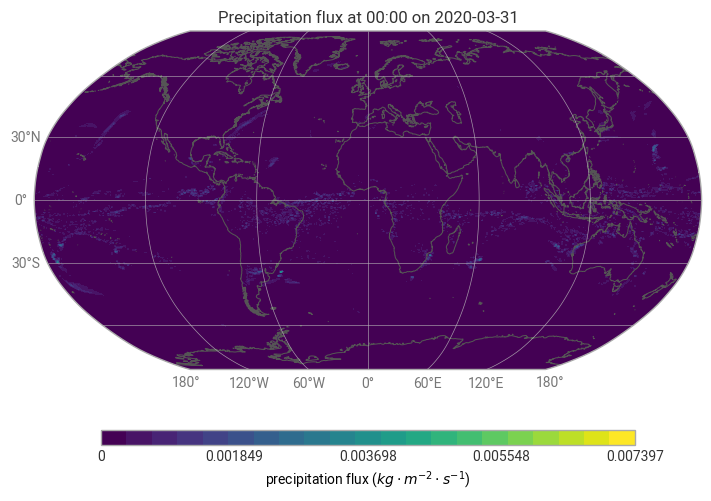

In [10]:
quickplot(
    da_pr,
    method="quickplot",
    chart=earthkit.plots.Map(crs="Robinson"),
    metadata={"gridSpec": gridspec},
)

The visualization with `pyicon` is shown below.

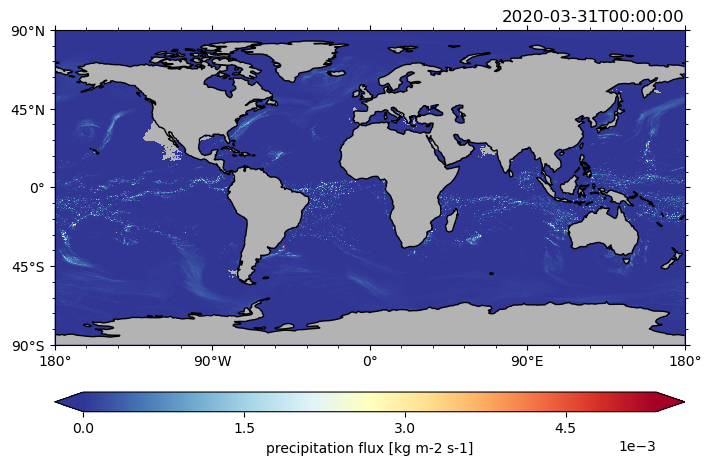

In [11]:
da_pr.pyic.plot()
plt.show()